In [11]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import imageio.v3 as iio
import ipympl

%matplotlib widget

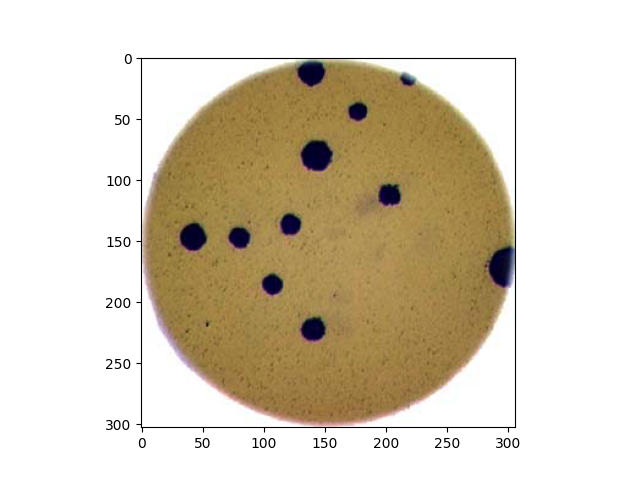

In [13]:
bacteria = iio.imread(uri='data/colonies-01.tif')

# display the image
fig, ax = plt.subplots()
ax.imshow(bateria)

/tmp/ipykernel_9840/1404917556.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


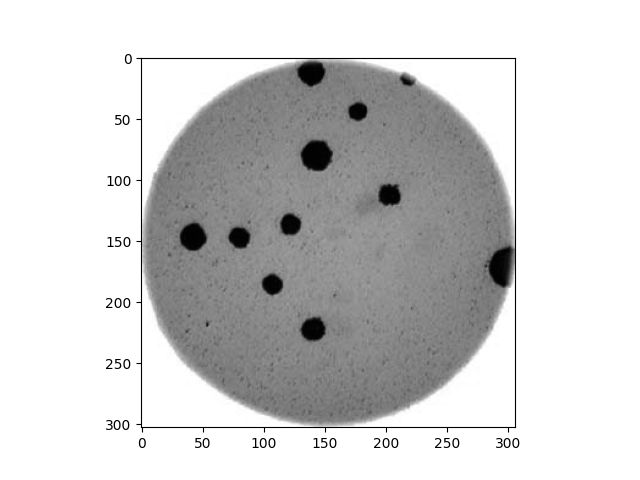

In [15]:
gray_bacteria = ski.color.rgb2gray(bacteria)

# display the image
fig, ax = plt.subplots()
ax.imshow(gray_bacteria, cmap='gray')

(0.0, 1.0)

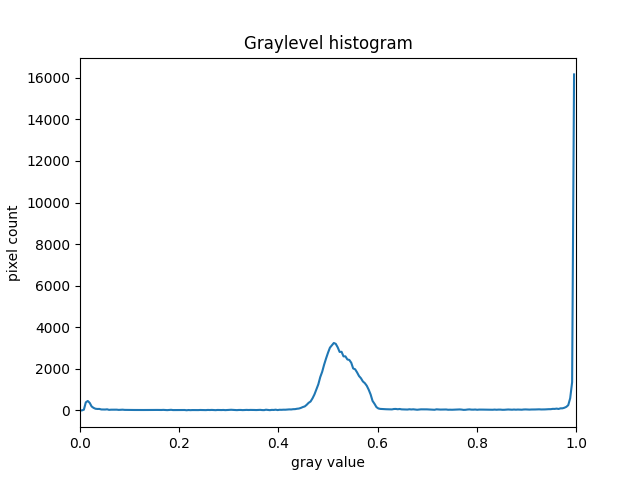

In [17]:
blurred_image = ski.filters.gaussian(gray_bacteria, sigma=1.0)

histogram, bin_edges = np.histogram(
    blurred_image,
    bins=256,
    range=(0.0, 1.0)
)

fig, ax = plt.subplots()
ax.set_title('Graylevel histogram')
ax.plot(bin_edges[0:-1], histogram)
ax.set_ylabel('pixel count')
ax.set_xlabel('gray value')
ax.set_xlim(0, 1.0)

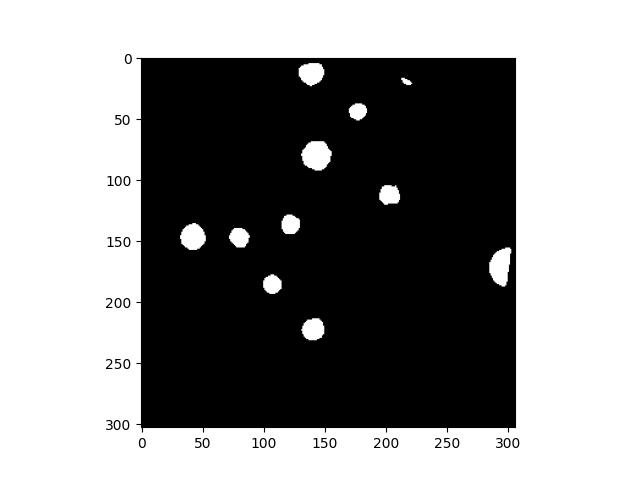

In [18]:
mask = blurred_image < 0.2
fig, ax = plt.subplots()
ax.imshow(mask, cmap='gray')

In [19]:
labeled_image, count = ski.measure.label(
    mask,
    return_num=True
)
print(count)

11


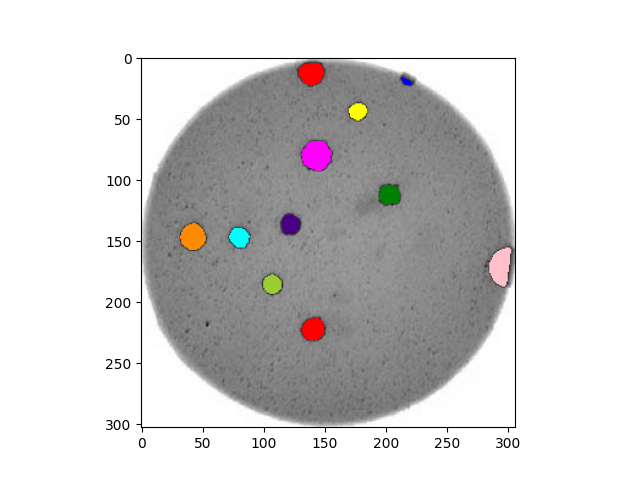

In [20]:
# color each of the colonies a different color
colored_label_image = ski.color.label2rgb(
    labeled_image, 
    bg_label=0
)

# give our grayscale image rgb channels, 
# so we can add the colored colonies
summary_image = ski.color.gray2rgb(gray_bacteria)
summary_image[mask] = colored_label_image[mask]

# plot overlay
fig, ax = plt.subplots()
ax.imshow(summary_image)

In [32]:
def count_colonies(image_filename):
    bacteria_image = iio.imread(image_filename)
    gray_bacteria = ski.color.rgb2gray(bacteria_image)
    blurred_image = ski.filters.gaussian(gray_bacteria, sigma=1.0)
    mask = blurred_image < 0.2
    labeled_image, count = ski.measure.label(mask, return_num=True)
    print(f'There are {count} colonies in {image_filename}')

    colored_label_image = ski.color.label2rgb(labeled_image, bg_label=0)
    summary_image = ski.color.gray2rgb(gray_bacteria)
    summary_image[mask] = colored_label_image[mask]
    fig, ax = plt.subplots()
    ax.imshow(summary_image)

In [33]:
for image_filename in [
    'data/colonies-01.tif', 
    'data/colonies-02.tif', 
    'data/colonies-03.tif',
]:
    count_colonies(image_filename=image_filename)

There are 11 colonies in data/colonies-01.tif
There are 74 colonies in data/colonies-02.tif
There are 333 colonies in data/colonies-03.tif


In [34]:
def count_colonies_enhanced(
    image_filename, 
    sigma=1.0, 
    min_colony=10,
    connectivity=2
):
    bacteria_image = iio.imread(image_filename)
    gray_bacteria = ski.color.rgb2gray(bacteria_image)
    blurred_image = ski.filters.gaussian(
        gray_bacteria,
        sigma=sigma
    )

    # create mask excluding the very bright pixels
    # outside the dish. we dont want to include
    # these when calculating the automated threshold
    mask = blurred_image < 0.9
    # calculate an automated threshold value within 
    # the dish using the Otsu method
    t = ski.filters.threshold_otsu(blurred[mask])
    # update mask to select pixels both with the dish
    # and less than t
    mask = np.logical_and(mask, blurred_image < t)
    # remove objects smaller than specified area
    mask = ski.morphology.remove_small_objects(
        mask, 
        min_size=min_colony_size
    )

    labeled_image, count = ski.measure.label(mask, return_num=True)
    print(f'There are {count} colonies in {image_filename}')
    colored_label_image = ski.color.label2rgb(labeled_image, bg_label=0)
    summary_image = ski.color.gray2rgb(gray_bacteria)
    summary_image[mask] = colored_label_image[mask]
    fig, ax = plt.subplots()
    ax.imshow(summary_image)

There are 11 colonies in data/colonies-01.tif
There are 74 colonies in data/colonies-02.tif
There are 333 colonies in data/colonies-03.tif


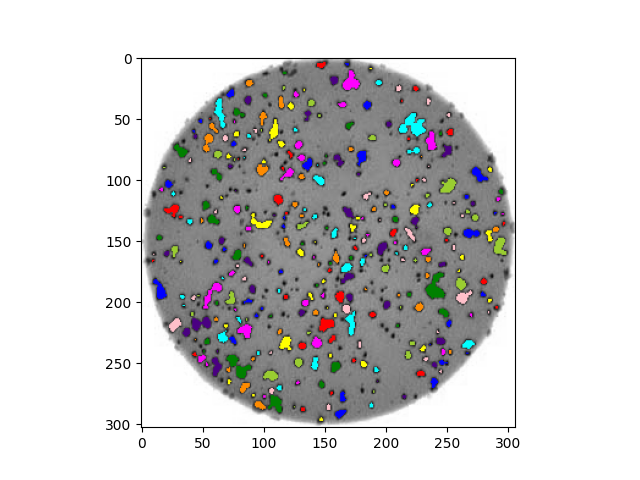

In [36]:
for image_filename in [
    'data/colonies-01.tif', 
    'data/colonies-02.tif', 
    'data/colonies-03.tif',
]:
    count_colonies(image_filename=image_filename)